# Full experiment description (kidera factors)

## Importing and preparation

In [1]:
import sys
import os
from pathlib import Path
from omegaconf import OmegaConf
import pandas as pd

project_root = Path().absolute().parent
sys.path.append(str(project_root))

### Path preparation

In [2]:
%cd ..

/Users/alex/Edu/Bioinformatics_institute/Project/Vlasova/gitlab


/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
output_dir = 'full_exp_kidera'
weights_suf = 'weights'
report_suf = 'report'
embds_suf = 'embds'

### Constants

In [4]:
embd_type = 'kidera'

## Import TCREnc scripts

In [5]:
from tcrenc.tcrenc_run import main as tcrenc_run_main
from tcrenc.tcrenc_train import main as tcrenc_train_main
from tcrenc.tcrenc_validate import main as tcrenc_validate_main

/Users/alex/miniconda3/envs/tcreppred_sil2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Kidera factors sequence representation experiment

Let's try to train autoencoder for kidera factors representation.
General pipeline:
```
1.configure model parameters ->  2. train model ->  3. Validate it on some test data -> 4. Make embeddings for future use
```

### 1.Model configuration

In [6]:
with open('./tcrenc/configs/config_general.yaml') as f:
    general_config = OmegaConf.load(f)
print('General configurations:\n', general_config)

with open('./tcrenc/configs/config_kidera.yaml') as f:
    special_config = OmegaConf.load(f)
print('Special models configurations:\n', special_config)

General configurations:
 {'USE_GPU': True, 'LATENT_DIMS': 64, 'MIN_CDR3_LEN': 11, 'MAX_CDR3_LEN': 19, 'MAX_EPITOPE_LEN': 20, 'MIN_EPITOPE_LEN': 6}
Special models configurations:
 {'general': {'LINEAR_PART_CDR3': 19, 'LINEAR_PART_EPITOPE': 20, 'BATCH_SIZE': 64, 'LOSS_FUNCTION': {'_component_': 'torch.nn.BCEWithLogitsLoss'}}, 'train': {'EPOCH_NUM': 2, 'OPTIMIZER': {'_component_': 'torch.optim.Adam', 'lr': 0.0001, 'weight_decay': 0}}, 'validate': {'WEIGHTS_CDR3': 'full_exp_kidera/weights/weights_kidera_cdr3.pth', 'WEIGHTS_EPIOPE': 'full_exp_kidera/weights/weights_kidera_antigen_epitope.pth'}, 'run': {'WEIGHTS_CDR3': 'full_exp_kidera/weights/weights_kidera_cdr3.pth', 'WEIGHTS_EPIOPE': 'full_exp_kidera/weights/weights_kidera_antigen_epitope.pth'}}


* You can change parameters manually, or reassign some values here and save the dictionaries to the path specified below.

In [7]:
# with open('./tcrenc/configs/config_general.yaml') as f:
#     general_config = OmegaConf.load(f)

# # Update
# general_config['LATENT_DIMS'] = 64

# with open('./tcrenc/configs/config_general.yaml', 'w') as f:
#     OmegaConf.save(general_config, f)

### 2. Model training 

#### Prepare training data

For epitope training we will use data from IEDB with following filters:
- linear peptides
- host: human

For cdr3 training we will use VDJdb.

#### Epitope model train

In [ ]:
script_name = 'tcrenc_train'

val_args = {
  "--input":'./dataset/epitopes_for_train/epitopes.csv',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, weights_suf),
  '--split': '0.8'
}
logic_args = [
    "--weights_save"
    #'--cdr',
    #'--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [9]:
tcrenc_train_main(sys.argv)

Training model for antigen_epitope ...
[0/2] Train Loss: 0.6728 | Test Loss: 0.6459
Train for antigen_epitope finished
Average reconstruction error of antigen_epitope sequences on sample: 0.6397
Start UMAP training for antigen_epitope


UMAP training for antigen_epitope finished!


Start RandomForestClassifier training for antigen_epitope


RandomForestClassifier training for antigen_epitope finished!


Classification report for full model:

              precision    recall  f1-score   support

           0       0.44      0.42      0.43     32465
           1       0.94      0.78      0.85     20687
           2       0.94      0.77      0.84     15572
           3       0.93      0.75      0.83     18787
           4       0.83      0.61      0.70      3886
           5       0.85      0.69      0.76     17867
           6       0.83      0.70      0.76     26722
           7       0.92      0.74      0.82     24503
           8       0.83      0.70      0.76      9495
           9 

#### Update weights in config

In [10]:
with open('./tcrenc/configs/config_kidera.yaml') as f:
    special_config = OmegaConf.load(f)

old_ep_weights = special_config['validate']['WEIGHTS_EPIOPE']
# Update
special_config['validate']['WEIGHTS_EPIOPE'] = os.path.join(output_dir, weights_suf, 'weights_kidera_antigen_epitope.pth')

with open('./tcrenc/configs/config_kidera.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

#### CDR3 model train

In [11]:
script_name = 'tcrenc_train'

val_args = {
  "--input":'VDJdb',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, weights_suf),
  '--split': '0.8'
}
logic_args = [
    "--weights_save",
    '--cdr',
    #'--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [12]:
tcrenc_train_main(sys.argv)

Training model for cdr3 ...
[0/2] Train Loss: 0.6766 | Test Loss: 0.6490
Train for cdr3 finished
Average reconstruction error of cdr3 sequences on sample: 0.6278
Start UMAP training for cdr3


UMAP training for cdr3 finished!


Start RandomForestClassifier training for cdr3


RandomForestClassifier training for cdr3 finished!


Classification report for full model:

              precision    recall  f1-score   support

           0       0.90      0.89      0.89     16880
           1       0.99      0.97      0.98      5107
           2       0.99      0.98      0.99      4853
           3       0.94      0.96      0.95      4700
           4       0.99      1.00      0.99     11243
           5       0.95      0.96      0.95     10478
           6       0.90      0.93      0.92      9357
           7       1.00      0.98      0.99     16510
           8       0.94      0.83      0.88      1859
           9       0.71      0.66      0.69      2046
          10       0.94      0.91   

#### Update weights in config

In [13]:
with open('./tcrenc/configs/config_kidera.yaml') as f:
    special_config = OmegaConf.load(f)

old_cdr_weights = special_config['validate']['WEIGHTS_CDR3']
# Update
special_config['validate']['WEIGHTS_CDR3'] = os.path.join(output_dir, weights_suf,'weights_kidera_cdr3.pth')

with open('./tcrenc/configs/config_kidera.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

### 3. Model validation 

In [7]:
script_name = 'tcrenc_validate'

val_args = {
  "--input":'VDJdb',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, report_suf),
}
logic_args = [
    # "--weights_save",
    # '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

Average reconstruction error of cdr3 sequences on sample: 0.6278
Average reconstruction error of antigen_epitope sequences on sample: 0.6335
All files saved!


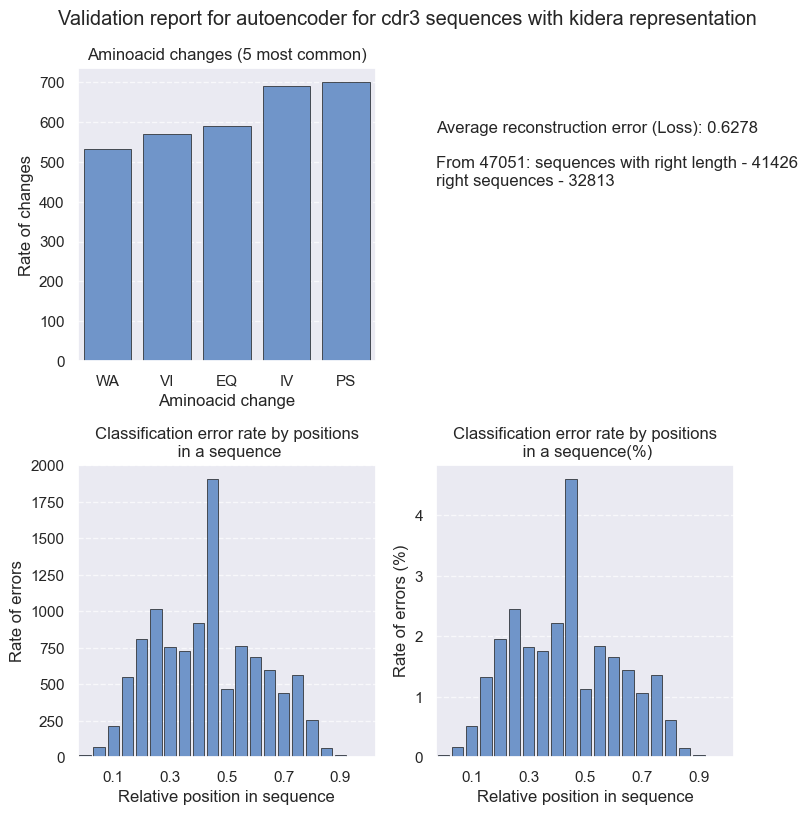

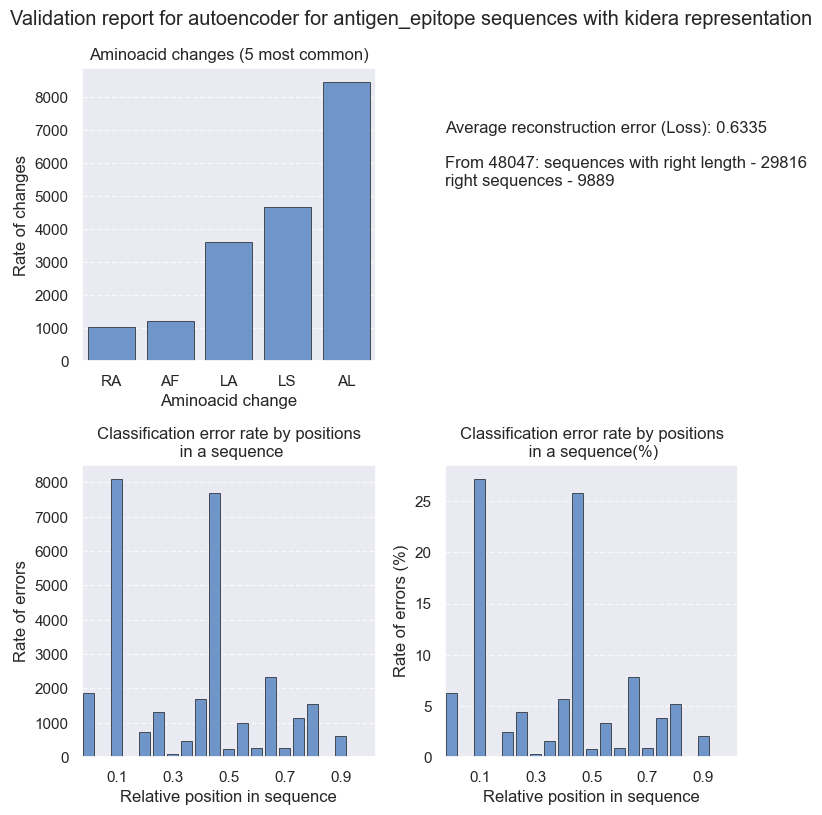

In [8]:
tcrenc_validate_main(sys.argv)

### 4. Make embeddings with trained model

#### Update config

In [9]:
with open('./tcrenc/configs/config_kidera.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['run']['WEIGHTS_EPIOPE'] = os.path.join(output_dir, weights_suf, 'weights_kidera_antigen_epitope.pth')
special_config['run']['WEIGHTS_CDR3'] = os.path.join(output_dir, weights_suf,'weights_kidera_cdr3.pth')

with open('./tcrenc/configs/config_kidera.yaml', 'w') as f:
    OmegaConf.save(special_config, f)

#### Make embeddings

In [7]:
script_name = 'tcrenc_run'

val_args = {
  "--input": 'VDJdb',
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, embds_suf),
}
logic_args = [
    # '--decoder',
    # '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [8]:
tcrenc_run_main(sys.argv)

full_exp_kidera/embds/embeddings_cdr3_kidera.csv file saved!
full_exp_kidera/embds/embeddings_antigen_epitope_kidera.csv file saved!
All files saved!


#### Use new embeddings to reconstruct sequences (Use our model as decoder)

In [9]:
df = pd.read_csv(os.path.join(output_dir, embds_suf, 'embeddings_cdr3_kidera.csv'))
df.drop(columns='cdr3', inplace=True)
df.to_csv(os.path.join(output_dir, embds_suf, 'embeddings_cdr3_kidera_for_decoder.csv'), index=False)

In [10]:
script_name = 'tcrenc_run'

val_args = {
  "--input": os.path.join(output_dir, embds_suf, 'embeddings_cdr3_kidera_for_decoder.csv'),
  '--embed_type':embd_type,
  '--output':os.path.join(output_dir, embds_suf),
}
logic_args = [
    '--decoder',
    '--cdr',
    # '--epitope'
]

argv_for_run = [script_name]
[argv_for_run.extend([k,v]) for k,v in val_args.items()]
if len(logic_args) != 0:
    argv_for_run.extend(logic_args)

sys.argv = argv_for_run

In [11]:
tcrenc_run_main(sys.argv)

full_exp_kidera/embds/reconstructed_cdr3_kidera.csv file saved!
All files saved!


#### Re-update weights

In [ ]:
with open('./tcrenc/configs/config_kidera.yaml') as f:
    special_config = OmegaConf.load(f)

# Update
special_config['run']['WEIGHTS_EPIOPE'] = old_ep_weights
special_config['validate']['WEIGHTS_EPIOPE'] = old_ep_weights
special_config['run']['WEIGHTS_CDR3'] = old_cdr_weights
special_config['validate']['WEIGHTS_CDR3'] = old_cdr_weights 

with open('./tcrenc/configs/config_kidera.yaml', 'w') as f:
    OmegaConf.save(special_config, f)